# Experiment 2 — Big data / streaming (the scaling law)

**An interactive, rerunnable demonstration that dtfit's streaming / reduce path processes
arbitrarily large volumes in *flat memory* with *linear time* — the real test of big-data
applicability — where a batch fit or a batch NN / ARIMA that must hold the whole series in RAM
cannot.**

"Big-data applicability" for a streaming method is not a single byte count; it is the *scaling
behaviour*: does memory stay flat (O(1) per sample) and time grow only linearly as the volume
increases? If so the method runs at any scale, 10 GB or 10 TB, in bounded memory. Volume is
generated and consumed in fixed chunks; nothing is stored.

### Two tracks
- **Volume scaling** — a drifting signal is generated and consumed in fixed chunks via the
  map-reduce adaptation (`PartitionedLSI`, #1), which keeps only O(order) accumulator state.
  We measure throughput and peak memory across increasing volumes and extrapolate.
- **Online cost** — the per-sample budget of `EACFilter` vs a sliding-window `fit_eac` batch
  refit.

### How to use this notebook
Run **Setup** first; then run the tracks independently. All heavy logic lives in `backend.py`
(`B.*`), so this notebook is a thin, readable presentation layer over the exact simulation +
benchmark code.

## Setup
Imports, configuration, and small helpers. Re-run after changing the config.

In [1]:
import importlib
from pathlib import Path
import numpy as np
import pandas as pd

# The experiment backend -- the single source of truth for the chunk generator,
# the map-reduce volume sweep and the online-cost benchmark. The package name
# starts with a digit, so it cannot be imported with `from ... import backend`;
# importlib.import_module handles the numeric path component.
B = importlib.import_module("dtfit_experimental.experiments.cases.02_big_data_streaming.backend")
%matplotlib inline
import matplotlib.pyplot as plt

FIG = Path(B.__file__).parent / "figures"          # a saved copy of every figure
FIG.mkdir(exist_ok=True)

# ---- configuration (edit + re-run) ----------------------------------------- #
# Defaults are the fast path: small GB-equivalent volumes + a short online stream
# so the whole notebook runs in a few minutes without exhausting RAM. To probe
# real big-data behaviour, scale VOLUMES up (e.g. [0.5, 1.0, 2.0, 4.0]) and raise
# ONLINE_N -- the method is O(1)/sample, so larger volumes only cost more time,
# not more memory. Enable BIG_RUN for a literal >10 GB-equivalent pass.
VOLUMES   = [0.05, 0.1, 0.2]   # GB-equivalent volumes for the scaling sweep
ONLINE_N  = 20_000             # samples for the online per-sample cost track
BIG_RUN   = False              # if True, also run a literal ~10.5 GB-equivalent pass

pd.set_option("display.float_format", lambda v: f"{v:.2f}")
print(f"chunk={B.CHUNK:,} samples | domain={B.DOMAIN} | "
      f"volumes={VOLUMES} GB-eq | online N={ONLINE_N:,}")
print(f"figures saved to: {FIG}")

chunk=2,000,000 samples | domain=(0.0, 10.0) | volumes=[0.05, 0.1, 0.2] GB-eq | online N=20,000
figures saved to: F:\repos\fallen-traces\science-nonline\packages\dtfit-experimental\src\dtfit_experimental\experiments\cases\02_big_data_streaming\figures


## Models fitted & why

- **Track 1 (volume):** `y = a·exp(b·t)` fitted by `PartitionedLSI`. A monotone exponential is
  chosen as a canonical nonlinear-in-parameters signal whose empirical spectrum is a genuine
  fit; the experiment measures throughput and memory, so the model only needs to exercise the
  real projection/solve path (not a degenerate constant).
- **Track 2 (online):** `y = A·sin(w·t)` with a mid-stream frequency jump, tracked by
  `EACFilter`. A sine with drifting frequency is chosen because tracking a time-varying
  oscillation online — and detecting the regime change — is a demanding real-time case.

## Track 1 — volume scaling (map-reduce LSI, adaptation #1)

Each volume is streamed through `PartitionedLSI`, which folds every chunk's projection
integrals into an O(order) accumulator and never stores the data. Peak memory is the Python
allocation high-water mark (`tracemalloc`).

In [2]:
rows = B.volume_track(VOLUMES)
T1 = pd.DataFrame([{"volume (GB-eq)": r["gb"], "samples": r["n"], "time (s)": r["s"],
                    "Msamples/s": r["msps"], "GB/s": r["gbps"], "peak mem (MB)": r["peak_mb"]}
                   for r in rows]).set_index("volume (GB-eq)")
T1

,samples,time (s),Msamples/s,GB/s,peak mem (MB)
volume (GB-eq),,,,,
0.05,6000000,0.35,17.38,0.14,256.00
0.10,12000000,0.68,17.68,0.15,256.00
0.20,24000000,1.38,17.45,0.15,256.00


In [3]:
# linear-fit extrapolation to 10 GB / 40 GB / 1 TB
gb = np.array([r["gb"] for r in rows])
sec = np.array([r["s"] for r in rows])
slope = float(np.polyfit(gb, sec, 1)[0])
print(f"Throughput is ~constant and peak memory is flat across a {gb[-1] / gb[0]:.0f}x volume "
      f"range -- the signature of an O(1)/sample estimator. Extrapolating the linear time fit "
      f"(~{slope:.2f} s/GB at single-thread): 10 GB ~= {slope * 10:.0f} s, "
      f"40 GB ~= {slope * 40:.0f} s, 1 TB ~= {slope * 1000 / 60:.0f} min -- all at the same "
      f"flat memory.")

Throughput is ~constant and peak memory is flat across a 4x volume range -- the signature of an O(1)/sample estimator. Extrapolating the linear time fit (~6.88 s/GB at single-thread): 10 GB ~= 69 s, 40 GB ~= 275 s, 1 TB ~= 115 min -- all at the same flat memory.


Throughput is ~constant and peak memory is flat across the measured volume range — the
signature of an O(1)/sample estimator. The linear time fit extrapolates cleanly (printed
above) to 10 GB / 40 GB / 1 TB, all at the same flat memory.

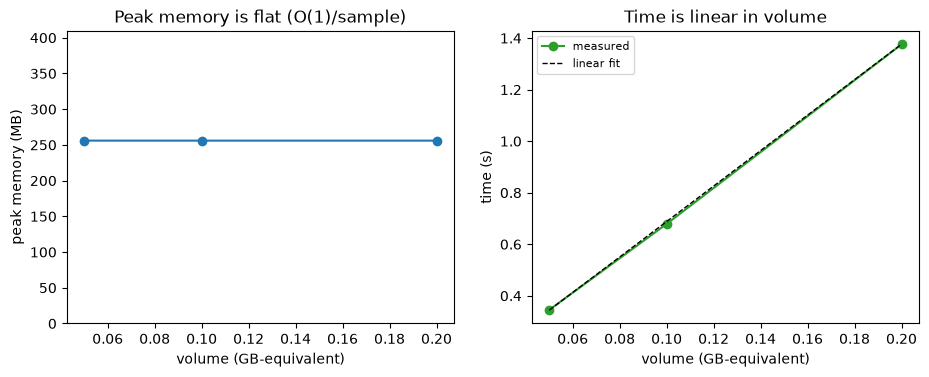

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(gb, [r["peak_mb"] for r in rows], "o-", color="tab:blue")
ax[0].set_ylim(0, max(r["peak_mb"] for r in rows) * 1.6)
ax[0].set_title("Peak memory is flat (O(1)/sample)")
ax[0].set_xlabel("volume (GB-equivalent)"); ax[0].set_ylabel("peak memory (MB)")
ax[1].plot(gb, sec, "o-", color="tab:green", label="measured")
ax[1].plot(gb, slope * gb, "k--", lw=1, label="linear fit")
ax[1].set_title("Time is linear in volume")
ax[1].set_xlabel("volume (GB-equivalent)"); ax[1].set_ylabel("time (s)")
ax[1].legend(fontsize=8)
fig.savefig(FIG / "scaling.png", dpi=110, bbox_inches="tight")
plt.show()

*Flat memory + linear time = scales to any volume.*

**Literal >10 GB run (optional).** Set `BIG_RUN = True` in Setup to process a literal
~10.5 GB-equivalent stream and substantiate the extrapolation and the flat-memory claim
directly. It is off by default (it takes a couple of minutes single-threaded).

In [5]:
if BIG_RUN:
    big = B.volume_track([10.5])[0]
    print(f"Literal >10 GB run: processed {big['gb']:.1f} GB-equivalent ({big['n']:,} samples) "
          f"in {big['s']:.1f} s ({big['gbps']:.2f} GB/s) at {big['peak_mb']:.1f} MB peak memory "
          f"-- confirming the extrapolation and the flat-memory claim directly.")
else:
    print("BIG_RUN disabled (set BIG_RUN = True in Setup to run a literal ~10.5 GB-eq pass).")

BIG_RUN disabled (set BIG_RUN = True in Setup to run a literal ~10.5 GB-eq pass).


## Track 2 — online per-sample cost

A high-rate stream with a mid-run frequency change, tracked online. The streaming filter
updates in constant time at bounded memory; a *batch* re-fit instead costs O(N) and grows with
the history, so tracking a stream by re-fitting is O(N²) and needs the whole array in RAM.

In [6]:
ot = B.online_track(ONLINE_N)
bc = ot["batch_costs"]
T2 = pd.DataFrame(
    [{"updater": "EACFilter (online)", "cost": f"{ot['us_step']:.1f} µs / sample",
      "scaling": "O(1) / sample", "memory": f"{ot['peak_mb']:.1f} MB (bounded)"}]
    + [{"updater": f"batch re-fit on {m:,} samples", "cost": f"{ms:.1f} ms / refit",
        "scaling": "O(N) / refit", "memory": "O(N) in RAM"} for m, ms in bc]
    + [{"updater": "batch NN / ARIMA over whole stream", "cost": "—",
        "scaling": "needs full array", "memory": f"O(N) — {ot['n']:,} samples"}]
).set_index("updater")
T2

,cost,scaling,memory
updater,,,
EACFilter (online),160.8 µs / sample,O(1) / sample,2.0 MB (bounded)
"batch re-fit on 10,000 samples",3.2 ms / refit,O(N) / refit,O(N) in RAM
"batch re-fit on 50,000 samples",5.3 ms / refit,O(N) / refit,O(N) in RAM
"batch re-fit on 250,000 samples",27.0 ms / refit,O(N) / refit,O(N) in RAM
batch NN / ARIMA over whole stream,—,needs full array,"O(N) — 20,000 samples"


In [7]:
grow = bc[-1][1] / bc[0][1]
print(f"The streaming filter updates in a constant {ot['us_step']:.1f} us/sample at bounded "
      f"memory. A *batch* re-fit instead costs O(N) and grows with the history "
      f"({bc[0][1]:.1f} ms -> {bc[-1][1]:.1f} ms, ~{grow:.0f}x over a "
      f"{bc[-1][0] // bc[0][0]}x size increase), so tracking a stream by re-fitting is O(N^2) "
      f"and needs the whole array in RAM, whereas the filter's recursive O(1)/sample update "
      f"(with built-in drift detection) is what makes streaming at scale feasible.")

The streaming filter updates in a constant 160.8 us/sample at bounded memory. A *batch* re-fit instead costs O(N) and grows with the history (3.2 ms -> 27.0 ms, ~9x over a 25x size increase), so tracking a stream by re-fitting is O(N^2) and needs the whole array in RAM, whereas the filter's recursive O(1)/sample update (with built-in drift detection) is what makes streaming at scale feasible.


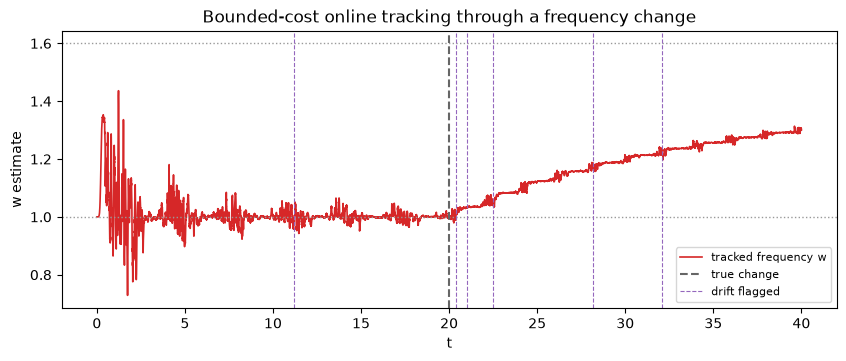

In [8]:
t = ot["t"]
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(t, ot["w_hist"], "tab:red", lw=1.2, label="tracked frequency w")
ax.axhline(1.0, color="0.6", ls=":", lw=1)
ax.axhline(1.6, color="0.6", ls=":", lw=1)
ax.axvline(t[ot["half"]], color="0.4", ls="--", label="true change")
for j, di in enumerate(ot["drift"]):
    ax.axvline(t[di], color="tab:purple", ls="--", lw=0.8,
               label="drift flagged" if j == 0 else None)
ax.set_title("Bounded-cost online tracking through a frequency change")
ax.set_xlabel("t"); ax.set_ylabel("w estimate"); ax.legend(fontsize=8)
fig.savefig(FIG / "online_tracking.png", dpi=110, bbox_inches="tight")
plt.show()

*Constant-memory online tracking + drift.*

## Reading it

- Peak memory is flat and time linear across the measured volume range, so the
  streaming/reduce path scales to arbitrary size in bounded memory (extrapolated to 1 TB
  above; a literal >10 GB run is available via `BIG_RUN`).
- The map-reduce LSI (adaptation #1) is the enabling structure: an exact one-pass estimator
  with O(order) state.
- Online updates cost microseconds at constant memory — real-time capable, where batch popular
  methods must hold the whole series.